In [1]:
import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
CONTRACTION_MAP = {
    # Standard English contractions
    "ain't": "is not", "aren't": "are not", "can't": "cannot", "couldn't": "could not",
    "didn't": "did not", "doesn't": "does not", "don't": "do not", "hadn't": "had not",
    "hasn't": "has not", "haven't": "have not", "he'd": "he would", "he'll": "he will",
    "he's": "he is", "i'd": "i would", "i'll": "i will", "i'm": "i am", "i've": "i have",
    "isn't": "is not", "it'd": "it would", "it'll": "it will", "it's": "it is",
    "let's": "let us", "mightn't": "might not", "mustn't": "must not", "shan't": "shall not",
    "she'd": "she would", "she'll": "she will", "she's": "she is", "shouldn't": "should not",
    "that's": "that is", "there's": "there is", "they'd": "they would", "they'll": "they will",
    "they're": "they are", "they've": "they have", "we'd": "we would", "we're": "we are",
    "we've": "we have", "weren't": "were not", "what's": "what is", "where's": "where is",
    "who's": "who is", "won't": "will not", "wouldn't": "would not", "you'd": "you would",
    "you'll": "you will", "you're": "you are", "you've": "you have",
    # Informal English contractions
    "'cause": "because", "'em": "them", "'bout": "about", "'til": "until", "'round": "around",
    "gonna": "going to", "wanna": "want to", "gimme": "give me", "lemme": "let me",
    "kinda": "kind of", "sorta": "sort of", "outta": "out of", "lotta": "lot of",
}

def fix_spaced_contractions(text):
    """Fix spaced contractions like "i' ve" -> "i've", "don' t" -> "don't"."""
    if not text:
        return ""

    spaced_contraction_patterns = [
        r"\b(\w+)\s+'\s+([a-z]{1,3})\b",  # "i ' ve" -> "i've"
        r"\b(\w+)'\s+([a-z]{1,3})\b",     # "don' t" -> "don't"
        r"\b(\w+)\s+'([a-z]{1,3})\b",     # "we 're" -> "we're"
    ]

    for pattern in spaced_contraction_patterns:
        text = re.sub(pattern, r"\1'\2", text, flags=re.IGNORECASE)

    return text

def expand_contractions(text):
    """Expand contractions to their full forms."""
    if not text:
        return ""

    # First fix spaced contractions
    text = fix_spaced_contractions(text)

    # Convert to lowercase for matching
    text_lower = text.lower()

    # Sort by length (longer first) to handle overlapping patterns
    contractions = sorted(CONTRACTION_MAP.keys(), key=len, reverse=True)

    for contraction in contractions:
        pattern = r'\b' + re.escape(contraction) + r'\b'
        replacement = CONTRACTION_MAP[contraction]
        text_lower = re.sub(pattern, replacement, text_lower)

    return text_lower

def preprocess_text_with_expansion(text):
    """Enhanced preprocessing with contraction expansion."""
    if not text or text == "N/A":
        return ""

    # First expand contractions
    text = expand_contractions(text)

    # Replace line breaks and tabs
    text = text.replace("\n", " ").replace("\t", " ").replace("\r", " ")

    # Remove emojis
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "\U0001F900-\U0001F9FF"
        "\U0001FA70-\U0001FAFF"
        "\U00002600-\U000026FF"
        "\U00002700-\U000027BF"
        "]+",
        flags=re.UNICODE
    )
    text = emoji_pattern.sub('', text)

    # Clean Unicode
    text = re.sub(r'[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]', '', text)
    text = re.sub(r'[^\w\s\.\,\!\?\;\:\-\_\(\)\[\]\{\}\"\'\`\~\@\#\$\%\^\&\*\+\=\|\\\/<>]', '', text, flags=re.UNICODE)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Punctuation spacing
    text = re.sub(r'([.!?,:;])\s*', r'\1 ', text)
    text = re.sub(r'\s*(["\'])', r' \1', text)
    text = re.sub(r'(["\'])\s*', r'\1 ', text)
    text = re.sub(r'\s*([(\[])', r' \1', text)
    text = re.sub(r'([)\]])\s*', r'\1 ', text)

    # Final cleanup
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [3]:
def load_and_preprocess_data(train_file, test_file):
    """Load and preprocess training and test data."""
    print("Loading training data...")
    train_data = pd.read_csv("datasets/enhanced_train.csv")

    print("Loading test data...")
    test_data = pd.read_csv("datasets/enhanced_test.csv")

    print(f"Original training data shape: {train_data.shape}")
    print(f"Original test data shape: {test_data.shape}")

    # Apply preprocessing
    print("Applying preprocessing to training data...")
    train_data['review'] = train_data['review'].apply(preprocess_text_with_expansion)

    print("Applying preprocessing to test data...")
    test_data['review'] = test_data['review'].apply(preprocess_text_with_expansion)

    # Remove empty reviews after preprocessing
    train_data = train_data[train_data['review'].str.len() > 0]
    test_data = test_data[test_data['review'].str.len() > 0]

    print(f"Training data shape after preprocessing: {train_data.shape}")
    print(f"Test data shape after preprocessing: {test_data.shape}")

    # Show sample preprocessed text
    print(f"\nSample preprocessed review: '{train_data['review'].iloc[0]}'")

    return train_data, test_data

In [4]:
def create_features(X_train, X_test):
    """Create TF-IDF features."""
    print("Creating TF-IDF features...")

    # Create feature extractors
    bow_vectorizer = CountVectorizer()
    tfidf_vectorizer = TfidfVectorizer()

    # Fit and transform the text data
    X_train_bow = bow_vectorizer.fit_transform(X_train)
    X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

    # Transform test data
    X_test_bow = bow_vectorizer.transform(X_test)
    X_test_tfidf = tfidf_vectorizer.transform(X_test)

    print(f"TF-IDF feature matrix shape: {X_train_tfidf.shape}")

    return (X_train_bow, X_train_tfidf, X_test_bow, X_test_tfidf,
            bow_vectorizer, tfidf_vectorizer)

In [5]:
def train_model(X_train_tfidf, y_train):
    """Train logistic regression model with hyperparameter tuning."""
    print("Training Logistic Regression with hyperparameter tuning...")

    lr_params = {'C': [0.1, 1, 10]}
    lr_grid = GridSearchCV(LogisticRegression(random_state=42), lr_params, cv=5)
    lr_grid.fit(X_train_tfidf, y_train)

    models = {'Logistic Regression': lr_grid.best_estimator_}
    print(f"Best LR params: {lr_grid.best_params_}")

    return models


In [6]:
def evaluate_model(model, X_test_tfidf, y_test):
    """Evaluate the logistic regression model and return results."""
    print("Evaluating Logistic Regression:")

    # Make predictions
    y_pred = model.predict(X_test_tfidf)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (weighted): {precision:.4f}")
    print(f"Recall (weighted): {recall:.4f}")
    print(f"F1 Score (weighted): {f1:.4f}")

    return results, y_pred

def get_model(models):
    """Get the logistic regression model."""
    model = models['Logistic Regression']
    print(f"Using Logistic Regression model")
    return model, 'Logistic Regression'

In [7]:
def plot_confusion_matrix(y_test, y_pred, model_name='Logistic Regression'):
    """Plot confusion matrix for the model."""
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.tight_layout()
    plt.show()

def plot_model_metrics(results, model_name='Logistic Regression'):
    """Plot model performance metrics."""
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    values = [results[metric] for metric in metrics]

    plt.figure(figsize=(10, 6))
    bars = plt.bar(metrics, values, color='skyblue', alpha=0.7)
    plt.title(f'{model_name} Performance Metrics')
    plt.ylabel('Score')
    plt.ylim(0, 1)

    # Add value labels on bars
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

In [8]:
def predict_sentiment(text, model, vectorizer):
    """Predict sentiment for a given text using logistic regression."""
    # Preprocess the input text
    preprocessed_text = preprocess_text_with_expansion(text)

    # Transform using the fitted vectorizer
    text_features = vectorizer.transform([preprocessed_text])

    # Make prediction
    prediction = model.predict(text_features)[0]

    # Get probability scores (logistic regression always has predict_proba)
    probabilities = model.predict_proba(text_features)[0]

    # Get class labels from the model
    class_labels = model.classes_
    confidence_scores = {
        class_labels[i]: probabilities[i] for i in range(len(class_labels))
    }

    # Map prediction to label
    predicted_label = class_labels[prediction] if prediction in range(len(class_labels)) else str(prediction)

    return predicted_label, confidence_scores, preprocessed_text

In [9]:
def main():
    """Main function to run the complete sentiment analysis pipeline."""
    print("=" * 60)
    print("SENTIMENT ANALYSIS WITH LOGISTIC REGRESSION")
    print("=" * 60)

    # 1. Load and preprocess data
    train_data, test_data = load_and_preprocess_data('enhanced_train.csv', 'enhanced_test.csv')

    # Separate features and labels
    X_train = train_data['review']
    y_train = train_data['label']
    X_test = test_data['review']
    y_test = test_data['label']

    # 2. Create features
    X_train_bow, X_train_tfidf, X_test_bow, X_test_tfidf, bow_vectorizer, tfidf_vectorizer = create_features(X_train, X_test)

    # 3. Train model
    models = train_model(X_train_tfidf, y_train)

    # 4. Get the model
    model, model_name = get_model(models)

    # 5. Evaluate model
    results, predictions = evaluate_model(model, X_test_tfidf, y_test)

    # 6. Visualizations
    print("\nGenerating visualizations...")
    plot_confusion_matrix(y_test, predictions, model_name)
    plot_model_metrics(results, model_name)

    # 7. Save the model and vectorizer
    print(f"\nSaving {model_name} model and vectorizer...")
    joblib.dump(model, 'LR_sentiment_model.pkl')
    joblib.dump(tfidf_vectorizer, 'LR_tfidf_vectorizer.pkl')
    print("Model and vectorizer saved successfully!")

    # 8. Interactive testing
    print("\n" + "=" * 60)
    print("INTERACTIVE SENTIMENT PREDICTION")
    print("=" * 60)

    while True:
        user_input = input("\nEnter a text to predict sentiment (or 'quit' to exit): ")

        if user_input.lower() == 'quit':
            break

        if user_input.strip():
            predicted_label, confidence_scores, preprocessed_text = predict_sentiment(
                user_input, model, tfidf_vectorizer
            )

            print(f"\nOriginal text: '{user_input}'")
            print(f"Preprocessed text: '{preprocessed_text}'")
            print(f"Predicted Sentiment: {predicted_label}")

            if confidence_scores:
                print("Confidence scores:")
                for sentiment, score in confidence_scores.items():
                    print(f"  {sentiment}: {score:.3f}")
        else:
            print("Please enter some text.")

    print("\nThank you for using the sentiment analyzer!")
    return model, tfidf_vectorizer, results

SENTIMENT ANALYSIS WITH LOGISTIC REGRESSION
Loading training data...
Loading test data...
Original training data shape: (10781, 2)
Original test data shape: (4463, 2)
Applying preprocessing to training data...
Applying preprocessing to test data...
Training data shape after preprocessing: (10781, 2)
Test data shape after preprocessing: (4463, 2)

Sample preprocessed review: 'high quality okay lang nmn yung items yung moskit ng bb is okay lang malaki sya pero yung bib lang diko nagustuhan kasi ang liliit baka di magkasya sa leeg ng bata'
Creating TF-IDF features...
TF-IDF feature matrix shape: (10781, 16202)
Training Logistic Regression with hyperparameter tuning...
Best LR params: {'C': 1}
Using Logistic Regression model
Evaluating Logistic Regression:
Accuracy: 0.8194
Precision (weighted): 0.8230
Recall (weighted): 0.8194
F1 Score (weighted): 0.8203

Generating visualizations...


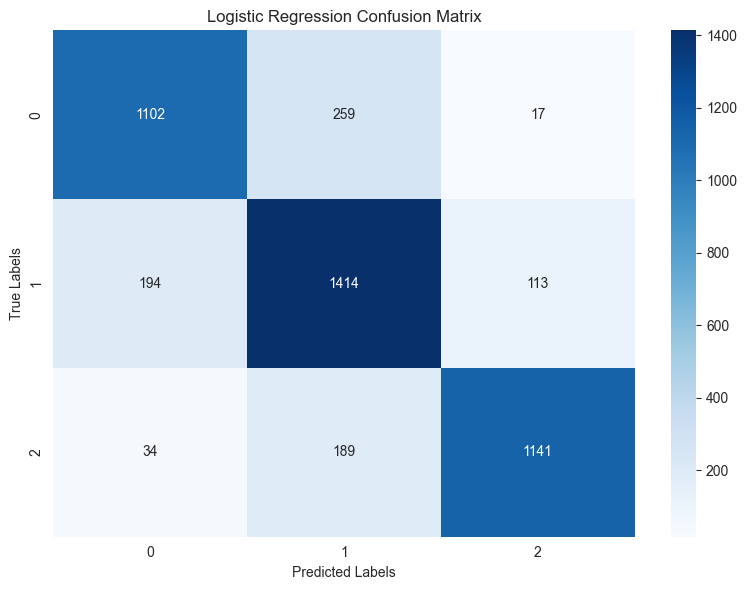

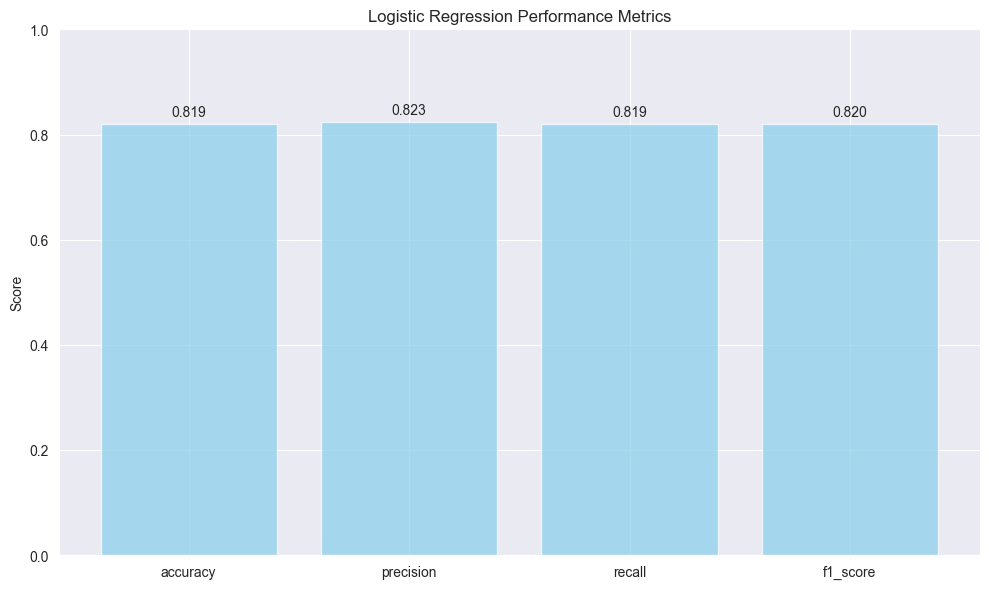


Saving Logistic Regression model and vectorizer...
Model and vectorizer saved successfully!

INTERACTIVE SENTIMENT PREDICTION

Original text: '🔨Durability:  Perfect for indoor and outdoor use, Durable and long-lasting, Versatile colors to match any outfit,'
Preprocessed text: 'durability: perfect for indoor and outdoor use, durable and long-lasting, versatile colors to match any outfit,'
Predicted Sentiment: 2
Confidence scores:
  0: 0.013
  1: 0.132
  2: 0.854


KeyboardInterrupt: Interrupted by user

In [10]:
if __name__ == "__main__":
    best_model, vectorizer, results = main()

In [15]:
def load_and_predict(text, model_path='LR_sentiment_model.pkl', vectorizer_path='LR_tfidf_vectorizer.pkl'):
    """Load saved model and make prediction."""
    try:
        # Load saved model and vectorizer
        model = joblib.load(model_path)
        vectorizer = joblib.load(vectorizer_path)

        # Make prediction
        predicted_label, confidence_scores, preprocessed_text = predict_sentiment(text, model, vectorizer)

        return {
            'original_text': text,
            'preprocessed_text': preprocessed_text,
            'predicted_sentiment': predicted_label,
            'confidence_scores': confidence_scores
        }

    except FileNotFoundError as e:
        print(f"Error: Could not find saved model files. {e}")
        return None
    except Exception as e:
        print(f"Error during prediction: {e}")
        return None

In [27]:
review = "rjgaer giroghr huherag;aerogaeurhahfaera31g54gargrghr"
load_and_predict(review)

{'original_text': 'rjgaer giroghr huherag;aerogaeurhahfaera31g54gargrghr',
 'preprocessed_text': 'rjgaer giroghr huherag; aerogaeurhahfaera31g54gargrghr',
 'predicted_sentiment': 'NEUTRAL',
 'confidence_scores': {'NEGATIVE': np.float64(0.3509921438914593),
  'NEUTRAL': np.float64(0.4582251266561243),
  'POSITIVE': np.float64(0.19078272945241642)}}

In [31]:
import pandas as pd
import numpy as np
import re
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer

# Preprocessing functions (copied from your training code)
CONTRACTION_MAP = {
    # Standard English contractions
    "ain't": "is not", "aren't": "are not", "can't": "cannot", "couldn't": "could not",
    "didn't": "did not", "doesn't": "does not", "don't": "do not", "hadn't": "had not",
    "hasn't": "has not", "haven't": "have not", "he'd": "he would", "he'll": "he will",
    "he's": "he is", "i'd": "i would", "i'll": "i will", "i'm": "i am", "i've": "i have",
    "isn't": "is not", "it'd": "it would", "it'll": "it will", "it's": "it is",
    "let's": "let us", "mightn't": "might not", "mustn't": "must not", "shan't": "shall not",
    "she'd": "she would", "she'll": "she will", "she's": "she is", "shouldn't": "should not",
    "that's": "that is", "there's": "there is", "they'd": "they would", "they'll": "they will",
    "they're": "they are", "they've": "they have", "we'd": "we would", "we're": "we are",
    "we've": "we have", "weren't": "were not", "what's": "what is", "where's": "where is",
    "who's": "who is", "won't": "will not", "wouldn't": "would not", "you'd": "you would",
    "you'll": "you will", "you're": "you are", "you've": "you have",
    # Informal English contractions
    "'cause": "because", "'em": "them", "'bout": "about", "'til": "until", "'round": "around",
    "gonna": "going to", "wanna": "want to", "gimme": "give me", "lemme": "let me",
    "kinda": "kind of", "sorta": "sort of", "outta": "out of", "lotta": "lot of",
}

def fix_spaced_contractions(text):
    """Fix spaced contractions like "i' ve" -> "i've", "don' t" -> "don't"."""
    if not text:
        return ""

    spaced_contraction_patterns = [
        r"\b(\w+)\s+'\s+([a-z]{1,3})\b",  # "i ' ve" -> "i've"
        r"\b(\w+)'\s+([a-z]{1,3})\b",     # "don' t" -> "don't"
        r"\b(\w+)\s+'([a-z]{1,3})\b",     # "we 're" -> "we're"
    ]

    for pattern in spaced_contraction_patterns:
        text = re.sub(pattern, r"\1'\2", text, flags=re.IGNORECASE)

    return text

def expand_contractions(text):
    """Expand contractions to their full forms."""
    if not text:
        return ""

    # First fix spaced contractions
    text = fix_spaced_contractions(text)

    # Convert to lowercase for matching
    text_lower = text.lower()

    # Sort by length (longer first) to handle overlapping patterns
    contractions = sorted(CONTRACTION_MAP.keys(), key=len, reverse=True)

    for contraction in contractions:
        pattern = r'\b' + re.escape(contraction) + r'\b'
        replacement = CONTRACTION_MAP[contraction]
        text_lower = re.sub(pattern, replacement, text_lower)

    return text_lower

def preprocess_text_with_expansion(text):
    """Enhanced preprocessing with contraction expansion."""
    if not text or text == "N/A":
        return ""

    # First expand contractions
    text = expand_contractions(text)

    # Replace line breaks and tabs
    text = text.replace("\n", " ").replace("\t", " ").replace("\r", " ")

    # Remove emojis
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "\U0001F900-\U0001F9FF"
        "\U0001FA70-\U0001FAFF"
        "\U00002600-\U000026FF"
        "\U00002700-\U000027BF"
        "]+",
        flags=re.UNICODE
    )
    text = emoji_pattern.sub('', text)

    # Clean Unicode
    text = re.sub(r'[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]', '', text)
    text = re.sub(r'[^\w\s\.\,\!\?\;\:\-\_\(\)\[\]\{\}\"\'\`\~\@\#\$\%\^\&\*\+\=\|\\\/\<\>]', '', text, flags=re.UNICODE)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Punctuation spacing
    text = re.sub(r'([.!?,:;])\s*', r'\1 ', text)
    text = re.sub(r'\s*(["\'])', r' \1', text)
    text = re.sub(r'(["\'])\s*', r'\1 ', text)
    text = re.sub(r'\s*([(\[])', r' \1', text)
    text = re.sub(r'([)\]])\s*', r'\1 ', text)

    # Final cleanup
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def predict_sentiment(text, model, vectorizer):
    """Predict sentiment for a given text."""
    # Preprocess the input text
    preprocessed_text = preprocess_text_with_expansion(text)

    # Transform using the fitted vectorizer
    text_features = vectorizer.transform([preprocessed_text])

    # Make prediction
    prediction = model.predict(text_features)[0]

    # Get probability scores if available
    if hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(text_features)[0]
        confidence_scores = {
            'NEGATIVE': probabilities[0],
            'NEUTRAL': probabilities[1],
            'POSITIVE': probabilities[2]
        }
    else:
        confidence_scores = None

    # Map prediction to label
    sentiment_labels = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}
    predicted_label = sentiment_labels[prediction]

    return predicted_label, confidence_scores, preprocessed_text

class SentimentPredictor:
    """A class to handle sentiment prediction with saved model."""

    def __init__(self, model_path='LR_sentiment_model.pkl', vectorizer_path='LR_tfidf_vectorizer.pkl'):
        """Initialize the predictor by loading the saved model and vectorizer."""
        try:
            self.model = joblib.load(model_path)
            self.vectorizer = joblib.load(vectorizer_path)
            print("✅ Model and vectorizer loaded successfully!")
        except FileNotFoundError as e:
            print(f"❌ Error: Could not find model files. {e}")
            self.model = None
            self.vectorizer = None
        except Exception as e:
            print(f"❌ Error loading model: {e}")
            self.model = None
            self.vectorizer = None

    def predict(self, text):
        """Make a sentiment prediction for the given text."""
        if self.model is None or self.vectorizer is None:
            return {"error": "Model not loaded properly"}

        try:
            predicted_label, confidence_scores, preprocessed_text = predict_sentiment(
                text, self.model, self.vectorizer
            )

            return {
                'original_text': text,
                'preprocessed_text': preprocessed_text,
                'predicted_sentiment': predicted_label,
                'confidence_scores': confidence_scores
            }
        except Exception as e:
            return {"error": f"Prediction failed: {e}"}

    def predict_and_print(self, text):
        """Make prediction and print results nicely."""
        result = self.predict(text)

        if "error" in result:
            print(f"❌ {result['error']}")
            return result

        print("=" * 60)
        print("SENTIMENT PREDICTION RESULT")
        print("=" * 60)
        print(f"📝 Original text: '{result['original_text']}'")
        print(f"🔧 Preprocessed text: '{result['preprocessed_text']}'")
        print(f"🎯 Predicted Sentiment: {result['predicted_sentiment']}")

        if result['confidence_scores']:
            print("📊 Confidence scores:")
            for sentiment, score in result['confidence_scores'].items():
                bar = "█" * int(score * 20)  # Simple progress bar
                print(f"  {sentiment:8}: {score:.3f} {bar}")

        return result

# Example usage
if __name__ == "__main__":
    # Initialize the predictor
    predictor = SentimentPredictor()

    # Test with your review
    review = ("Scent:akajjanlamamammananznz s salama a amalaamama ammamaaamamamalaljdndkdueimslsjsue in nem "
              )

    # Make prediction
    result = predictor.predict_and_print(review)

✅ Model and vectorizer loaded successfully!
SENTIMENT PREDICTION RESULT
📝 Original text: 'Scent:akajjanlamamammananznz s salama a amalaamama ammamaaamamamalaljdndkdueimslsjsue in nem '
🔧 Preprocessed text: 'scent: akajjanlamamammananznz s salama a amalaamama ammamaaamamamalaljdndkdueimslsjsue in nem'
🎯 Predicted Sentiment: NEUTRAL
📊 Confidence scores:
  NEGATIVE: 0.298 █████
  NEUTRAL : 0.434 ████████
  POSITIVE: 0.268 █████
